# Do cheap heuristics reproduce Pearl-CM? Weight-halving and $\alpha=\sqrt{p}/q$

`alpha_pvs_relations.ipynb` found that the *optimal* Pearl damping obeys two equivalent laws:

- **half-weight:** the reweighted edge ends at $w_{\rm new}\approx\tfrac12 w_0$ (half its baseline log-odds weight);
- **$\sqrt{p}$ schedule:** $\alpha_{\rm opt}(p)\approx \sqrt{p}/q$, with $q=P(\mu\mid\nu)\approx0.065$.

Here we turn each law into a **parameter-free decoder** and test it against hard CM and MWPM:

- **Heuristic A — weight halving.** First-pass MWPM; then for *every edge whose correlated neighbour was
  selected*, set $w' = c\,w_0$ (default $c=\tfrac12$). No posteriors, no $\alpha$. Second-pass MWPM.
- **Heuristic B — $\sqrt{p}$ schedule.** Ordinary Pearl/damped CM with $\alpha$ fixed analytically to
  $\alpha=k\,\sqrt{p}/q$ (capped at 1), no per-$p$ tuning. Run natively with `decode_batch(alpha=...)`.
- **Heuristic C — geometric mean.** For each edge with a selected neighbour, set the implied probability to the
  geometric mean of prior and posterior, $p' = \sqrt{p_\mu\,P(\mu\mid\nu)}$ (equivalently $w' = \tfrac12(w_\mu+w_q)$,
  the log-space midpoint). Keeps the correlation strength but means the prior with $q<1$ instead of with certainty.

Baselines: **MWPM** and **CM ($\alpha=1$)**, on the same shots per $p$. $d=5$, rotated Z-memory, circuit-level
depolarizing.

**Reach caveat.** Directly measuring LER at $p\le10^{-4}$ (where hard CM crosses *above* MWPM) needs $\sim10^9$
shots, so the direct sweep runs $p\ge4\times10^{-4}$. For the sub-threshold crossover we overlay the
big-statistics `alpha_sweep_extended_fixed_MWPM.csv` (MWPM, CM $\alpha=1$, best-$\alpha$ oracle) down to $10^{-4}$, and draw
heuristic **B analytically** there (B is *exactly* CM at $\alpha=\sqrt{p}/q$, which we read off that sweep).

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import stim, pymatching

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
os.makedirs(os.path.join(ROOT, "data"), exist_ok=True); os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)
from adaptiveQRL.decompose_errors import decompose_errors_for_stim_surface_code_coords
from adaptiveQRL.decoding_graph import DecodingGraph
from adaptiveQRL.syndrome_data_generation import SyndromeDataGenerator

CFG = dict(distance=5, rounds=5,
           p_values=[4e-4, 7e-4, 1e-3, 2e-3, 5e-3, 1e-2],
           target_errors=120, chunk=100_000, max_shots=60_000_000, seed=2027,
           c_halve=[0.4, 0.5, 0.6],     # heuristic A: w' = c * w0
           out_csv="data/heuristic_reweight_test.csv")

def posterior_q(p=1e-3):
    gen = SyndromeDataGenerator(distance=CFG["distance"], n_rounds=CFG["rounds"], mismatch=1.0,
        noise_model={"version": "built-in", "after_clifford_depolarization": p,
                     "before_measure_flip_probability": p, "after_reset_flip_probability": p,
                     "before_round_data_depolarization": p, "p_gate_zz": 0.0},
        memory_type="z", n_shots=1, qec_code="surface_code")
    _, dem, _ = gen.generate_base_circuit(); g = DecodingGraph.from_dem(dem)
    corr = np.asarray(g.initial_corr_tracer); base = np.asarray(g.base_p); line = np.asarray(g.line_edge_index)
    a, b = line[0], line[1]
    return float(np.median(np.concatenate([corr / base[b], corr / base[a]])))
Q = posterior_q()
print(f"q = P(mu|nu) = {Q:.4f}");  print(CFG)

q = P(mu|nu) = 0.0654
{'distance': 5, 'rounds': 5, 'p_values': [0.0004, 0.0007, 0.001, 0.002, 0.005, 0.01], 'target_errors': 120, 'chunk': 100000, 'max_shots': 60000000, 'seed': 2027, 'c_halve': [0.4, 0.5, 0.6], 'out_csv': 'data/heuristic_reweight_test.csv'}


## Decoders

The first-pass selection `sel` is computed **once** per chunk and shared by MWPM and all halving variants;
the native CM decodes are deduplicated over the distinct $\alpha$ values. Halving only re-decodes the (few)
shots that actually have a reweight; the rest equal MWPM.

In [2]:
def build(p):
    circ = stim.Circuit.generated("surface_code:rotated_memory_z", distance=CFG["distance"], rounds=CFG["rounds"],
        after_clifford_depolarization=p, before_measure_flip_probability=p,
        after_reset_flip_probability=p, before_round_data_depolarization=p)
    dem = decompose_errors_for_stim_surface_code_coords(circ.detector_error_model(decompose_errors=False))
    g = DecodingGraph.from_dem(dem)
    fp = pymatching.Matching.from_check_matrix(g.H, weights=np.asarray(g.initial_weights))  # first pass / MWPM
    cm = pymatching.Matching.from_detector_error_model(dem, enable_correlations=True)         # CM / Pearl (native)
    cw = np.asarray(g.initial_weights, dtype=np.float64)
    src, dst = g.line_edge_index; E = g.n_dec_edges
    Aadj = sp.csr_matrix((np.ones(2 * len(src)), (np.r_[src, dst], np.r_[dst, src])), shape=(E, E))
    # precompute the geometric-mean reweight: implied' = sqrt(p_mu * P(mu|nu)) per directed line edge
    occ = np.asarray(g.base_p); corr = np.asarray(g.initial_corr_tracer)
    tgt = np.r_[src, dst]; srcn = np.r_[dst, src]; cc = np.r_[corr, corr]  # target<-source, both directions
    imp = np.clip(np.sqrt(occ[tgt] * cc / occ[srcn]), 1e-6, 0.499999)
    candw = np.log((1 - imp) / imp)                                        # candidate reweighted weight
    return dict(g=g, fp=fp, cm=cm, cw=cw, Aadj=Aadj, fault=np.asarray(g.fault_array, dtype=np.int64),
                tgt=tgt, srcn=srcn, candw=candw, sampler=circ.compile_detector_sampler(seed=CFG["seed"]))

def halve_from_sel(B, det, sel, rmask, idx, mwpm_pred, c):
    "Heuristic A: scale by c the weight of every edge with a selected neighbour; re-decode only active shots."
    g, fp, cw, fault = B["g"], B["fp"], B["cw"], B["fault"]
    pred = mwpm_pred.copy()
    if idx.size:
        rw = []
        for s in idx:
            nw = cw.copy(); m = rmask[s]; nw[m] = c * cw[m]
            rw.append(g.build_edge_reweights(nw, cw))
        ed = fp.decode_batch(det[idx], enable_correlations=False, edge_reweights=rw)
        pred[idx] = (np.asarray(ed, dtype=np.int64) @ fault) % 2
    return pred

def geom_from_sel(B, det, sel, idx, mwpm_pred):
    "Heuristic C: implied' = sqrt(p_mu * P(mu|nu)) on edges with a selected neighbour (strongest wins)."
    g, fp, cw, fault = B["g"], B["fp"], B["cw"], B["fault"]
    tgt, srcn, candw = B["tgt"], B["srcn"], B["candw"]
    pred = mwpm_pred.copy()
    if idx.size:
        rw = []
        for s in idx:
            act = sel[s][srcn]; nw = cw.copy()          # candidates whose source neighbour was selected
            if act.any():
                np.minimum.at(nw, tgt[act], candw[act])  # keep the lowest (strongest) reweight per edge
            rw.append(g.build_edge_reweights(nw, cw))
        ed = fp.decode_batch(det[idx], enable_correlations=False, edge_reweights=rw)
        pred[idx] = (np.asarray(ed, dtype=np.int64) @ fault) % 2
    return pred
print("decoders ready")

decoders ready


## Run the sweep (common shots per $p$)

In [3]:
rows = []; t_all = time.time()
names = ["mwpm", "cm1", "B_sqrt", "GEOM_q"] + [f"A_c{c}" for c in CFG["c_halve"]]
for p in CFG["p_values"]:
    B = build(p); fault = B["fault"]; Aadj = B["Aadj"]
    a_b = min(1.0, np.sqrt(p) / Q)                 # heuristic B alpha
    uniq = sorted({1.0, a_b})                      # dedup native decodes
    err = {n: 0 for n in names}; shots = 0; t0 = time.time()
    while err["cm1"] < CFG["target_errors"] and shots < CFG["max_shots"]:
        det, obs = B["sampler"].sample(shots=CFG["chunk"], separate_observables=True); obs = obs[:, 0].astype(np.int64)
        sel = np.asarray(B["fp"].decode_batch(det, enable_correlations=False), dtype=bool)
        mwpm_pred = (sel.astype(np.int64) @ fault) % 2
        dec = {a: np.asarray(B["cm"].decode_batch(det, enable_correlations=True, alpha=a), dtype=np.int64)[:, 0] for a in uniq}
        rmask = (Aadj.dot(sel.astype(np.int8).T).T) > 0; idx = np.flatnonzero(rmask.any(1))
        err["mwpm"] += int((mwpm_pred != obs).sum())
        err["cm1"] += int((dec[1.0] != obs).sum())
        err["B_sqrt"] += int((dec[a_b] != obs).sum())
        err["GEOM_q"] += int((geom_from_sel(B, det, sel, idx, mwpm_pred) != obs).sum())
        for cc in CFG["c_halve"]:
            err[f"A_c{cc}"] += int((halve_from_sel(B, det, sel, rmask, idx, mwpm_pred, cc) != obs).sum())
        shots += CFG["chunk"]
    r = {"p": p, "shots": shots, "alpha_b": a_b}
    for n in names:
        r[n] = err[n] / shots; r[n + "_std"] = (r[n] * (1 - r[n]) / shots) ** 0.5
    rows.append(r)
    ba = min(CFG["c_halve"], key=lambda cc: err[f"A_c{cc}"])
    print(f"p={p:<7g} shots={shots:>10,} a_b={a_b:.3f} | MWPM={r['mwpm']:.2e} CM1={r['cm1']:.2e} "
          f"B={r['B_sqrt']:.2e} GEOM={r['GEOM_q']:.2e} A(c={ba})={r['A_c'+str(ba)]:.2e} | "
          f"CM1/MW={r['cm1']/r['mwpm']:.3f} B/MW={r['B_sqrt']/r['mwpm']:.3f} "
          f"GEOM/MW={r['GEOM_q']/r['mwpm']:.3f} A05/MW={r['A_c0.5']/r['mwpm']:.3f} | "
          f"{time.time()-t0:.0f}s", flush=True)
df = pd.DataFrame(rows); df.to_csv(os.path.join(ROOT, CFG["out_csv"]), index=False)
print(f"\nsaved {CFG['out_csv']} | total {time.time()-t_all:.0f}s"); df

p=0.0004  shots=20,700,000 a_b=0.306 | MWPM=8.99e-06 CM1=5.80e-06 B=4.69e-06 GEOM=5.41e-06 A(c=0.6)=6.38e-06 | CM1/MW=0.645 B/MW=0.522 GEOM/MW=0.602 A05/MW=0.790 | 1198s


p=0.0007  shots= 4,500,000 a_b=0.405 | MWPM=4.18e-05 CM1=2.73e-05 B=2.20e-05 GEOM=2.60e-05 A(c=0.6)=3.04e-05 | CM1/MW=0.654 B/MW=0.527 GEOM/MW=0.622 A05/MW=0.851 | 417s


p=0.001   shots= 1,600,000 a_b=0.484 | MWPM=1.17e-04 CM1=8.06e-05 B=7.06e-05 GEOM=7.81e-05 A(c=0.6)=8.75e-05 | CM1/MW=0.686 B/MW=0.601 GEOM/MW=0.665 A05/MW=0.830 | 181s


p=0.002   shots=   300,000 a_b=0.684 | MWPM=1.02e-03 CM1=6.57e-04 B=6.23e-04 GEOM=6.93e-04 A(c=0.6)=7.33e-04 | CM1/MW=0.642 B/MW=0.609 GEOM/MW=0.678 A05/MW=0.814 | 51s


p=0.005   shots=   100,000 a_b=1.000 | MWPM=1.41e-02 CM1=1.02e-02 B=1.02e-02 GEOM=1.08e-02 A(c=0.6)=1.17e-02 | CM1/MW=0.724 B/MW=0.724 GEOM/MW=0.765 A05/MW=0.871 | 25s


p=0.01    shots=   100,000 a_b=1.000 | MWPM=8.07e-02 CM1=6.90e-02 B=6.90e-02 GEOM=7.05e-02 A(c=0.6)=7.52e-02 | CM1/MW=0.855 B/MW=0.855 GEOM/MW=0.874 A05/MW=0.975 | 34s



saved data/heuristic_reweight_test.csv | total 1908s


,p,shots,alpha_b,mwpm,mwpm_std,cm1,cm1_std,B_sqrt,B_sqrt_std,GEOM_q,GEOM_q_std,A_c0.4,A_c0.4_std,A_c0.5,A_c0.5_std,A_c0.6,A_c0.6_std
0,0.0004,20700000,0.305882,0.000009,6.588464e-07,0.000006,5.291990e-07,0.000005,4.757891e-07,0.000005,5.112549e-07,0.000008,6.280168e-07,0.000007,5.857156e-07,0.000006,5.550284e-07
1,0.0007,4500000,0.404644,0.000042,3.046894e-06,0.000027,2.464530e-06,0.000022,2.211059e-06,0.000026,2.403670e-06,0.000040,2.964756e-06,0.000036,2.810864e-06,0.000030,2.601005e-06
2,0.0010,1600000,0.483642,0.000117,8.569065e-06,0.000081,7.098349e-06,0.000071,6.643607e-06,0.000078,6.987439e-06,0.000112,8.384783e-06,0.000097,7.805867e-06,0.000087,7.394776e-06
3,0.0020,300000,0.683972,0.001023,5.837483e-05,0.000657,4.677020e-05,0.000623,4.556844e-05,0.000693,4.805735e-05,0.000887,5.434091e-05,0.000833,5.268266e-05,0.000733,4.942319e-05
4,0.0050,100000,1.000000,0.014070,3.724518e-04,0.010180,3.174329e-04,0.010180,3.174329e-04,0.010770,3.264048e-04,0.013310,3.623927e-04,0.012250,3.478496e-04,0.011700,3.400457e-04
5,0.0100,100000,1.000000,0.080700,8.613217e-04,0.068960,8.012772e-04,0.068960,8.012772e-04,0.070520,8.096106e-04,0.083490,8.747538e-04,0.078720,8.516053e-04,0.075220,8.340381e-04


## Sub-threshold context from the big-statistics sweep

Heuristic **B is exactly CM at $\alpha=\sqrt{p}/q$**, so we can extend it to $p=10^{-4}$ analytically by
log-interpolating the sweep's CM($\alpha$) LER at $\alpha=\sqrt{p}/q$ — no extra simulation. We also pull
MWPM, CM($\alpha=1$) and the best-$\alpha$ oracle from the sweep for the crossover region.

In [4]:
sw = pd.read_csv(os.path.join(ROOT, "data", "alpha_sweep_extended_fixed_MWPM.csv"))
sw["alpha"] = pd.to_numeric(sw["alpha"], errors="coerce")
d5 = sw[sw.distance == 5]
sw_p = np.array(sorted(d5.p.unique()))
def at(dec, p, alpha=None):
    s = d5[(d5.decoder == "mwpm") & (d5.p == p)] if dec == "mwpm" else \
        d5[(d5.decoder == "cm") & (d5.p == p) & np.isclose(d5.alpha, alpha)]
    return float(s.ler.iloc[0]) if len(s) else np.nan
sw_mwpm = np.array([at("mwpm", p) for p in sw_p])
sw_cm1 = np.array([at("cm", p, 1.0) for p in sw_p])
alphas = np.array(sorted(d5[d5.decoder == "cm"].alpha.dropna().unique()))
sw_best = np.array([min(at("cm", p, a) for a in alphas) for p in sw_p])
# analytic heuristic B: CM LER at alpha = sqrt(p)/q, log-interpolated over the alpha grid
def B_analytic(p):
    a_t = min(1.0, np.sqrt(p) / Q)
    lers = np.array([at("cm", p, a) for a in alphas])
    return float(np.exp(np.interp(a_t, alphas, np.log(lers))))
sw_B = np.array([B_analytic(p) for p in sw_p])
print("alpha grid:", alphas)
print(f"{'p':>7} {'a=sqrt(p)/q':>11} {'B(analytic)':>12} {'CM1':>10} {'MWPM':>10} {'B/MW':>6} {'CM1/MW':>7}")
for i, p in enumerate(sw_p):
    print(f"{p:>7.0e} {min(1,np.sqrt(p)/Q):>11.3f} {sw_B[i]:>12.2e} {sw_cm1[i]:>10.2e} {sw_mwpm[i]:>10.2e} "
          f"{sw_B[i]/sw_mwpm[i]:>6.3f} {sw_cm1[i]/sw_mwpm[i]:>7.3f}")

alpha grid: [0.05 0.1  0.15 0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.  ]
      p a=sqrt(p)/q  B(analytic)        CM1       MWPM   B/MW  CM1/MW
  1e-04       0.153     8.01e-08   1.68e-07   1.38e-07  0.582   1.224
  2e-04       0.216     5.59e-07   9.62e-07   1.06e-06  0.530   0.911
  4e-04       0.306     4.86e-06   6.04e-06   8.87e-06  0.548   0.682
  7e-04       0.405     2.55e-05   2.91e-05   4.60e-05  0.553   0.633
  1e-03       0.484     7.50e-05   7.96e-05   1.31e-04  0.573   0.609
  2e-03       0.684     6.04e-04   6.24e-04   1.00e-03  0.601   0.621
  4e-03       0.967     5.05e-03   5.06e-03   7.42e-03  0.680   0.682
  7e-03       1.000     2.65e-02   2.65e-02   3.40e-02  0.778   0.778
  1e-02       1.000     6.95e-02   6.95e-02   8.15e-02  0.853   0.853


## Plot

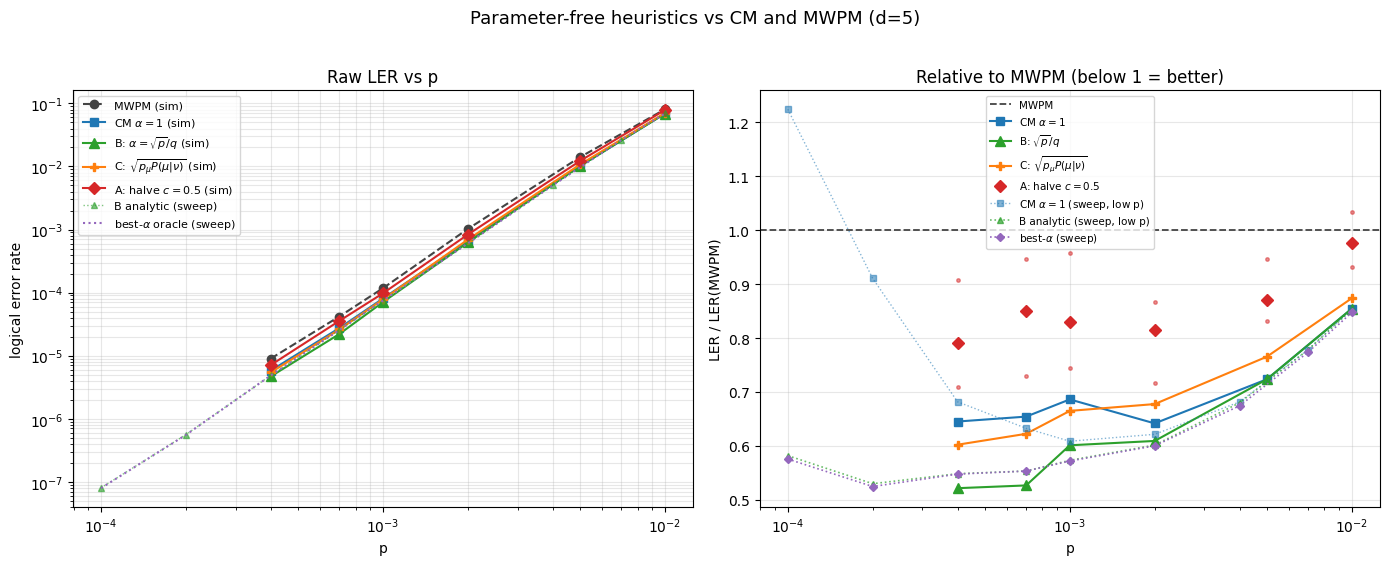

In [5]:
df = pd.read_csv(os.path.join(ROOT, CFG["out_csv"])); ps = df.p.to_numpy()
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
# ---- (1) raw LER ----
ax[0].loglog(ps, df.mwpm, "--o", color="#444", ms=6, label="MWPM (sim)")
ax[0].loglog(ps, df.cm1, "-s", color="#1f77b4", ms=6, label=r"CM $\alpha=1$ (sim)")
ax[0].loglog(ps, df.B_sqrt, "-^", color="#2ca02c", ms=7, label=r"B: $\alpha=\sqrt{p}/q$ (sim)")
ax[0].loglog(ps, df.GEOM_q, "-P", color="#ff7f0e", ms=6, label=r"C: $\sqrt{p_\mu P(\mu|\nu)}$ (sim)")
ax[0].loglog(ps, df["A_c0.5"], "-D", color="#d62728", ms=6, label=r"A: halve $c=0.5$ (sim)")
ax[0].loglog(sw_p, sw_B, ":^", color="#2ca02c", lw=1, ms=4, alpha=0.6, label=r"B analytic (sweep)")
ax[0].loglog(sw_p, sw_best, ":", color="#9467bd", lw=1.5, label=r"best-$\alpha$ oracle (sweep)")
ax[0].set_xlabel("p"); ax[0].set_ylabel("logical error rate"); ax[0].set_title("Raw LER vs p")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3, which="both")
# ---- (2) ratio to MWPM ----
ax[1].axhline(1.0, color="#444", ls="--", lw=1.3, label="MWPM")
ax[1].plot(ps, df.cm1 / df.mwpm, "-s", color="#1f77b4", ms=6, label=r"CM $\alpha=1$")
ax[1].plot(ps, df.B_sqrt / df.mwpm, "-^", color="#2ca02c", ms=7, label=r"B: $\sqrt{p}/q$")
ax[1].plot(ps, df.GEOM_q / df.mwpm, "-P", color="#ff7f0e", ms=6, label=r"C: $\sqrt{p_\mu P(\mu|\nu)}$")
for cc in CFG["c_halve"]:
    big = cc == 0.5
    ax[1].plot(ps, df[f"A_c{cc}"] / df.mwpm, "D" if big else ".", color="#d62728",
               ms=6 if big else 5, lw=1.8 if big else 0.8, alpha=1 if big else 0.5,
               label=(r"A: halve $c=0.5$" if big else None))
ax[1].plot(sw_p, sw_cm1 / sw_mwpm, ":s", color="#1f77b4", lw=1, ms=4, alpha=0.55, label=r"CM $\alpha=1$ (sweep, low p)")
ax[1].plot(sw_p, sw_B / sw_mwpm, ":^", color="#2ca02c", lw=1.2, ms=4, alpha=0.7, label=r"B analytic (sweep, low p)")
ax[1].plot(sw_p, sw_best / sw_mwpm, ":D", color="#9467bd", lw=1.2, ms=4, label=r"best-$\alpha$ (sweep)")
ax[1].set_xscale("log"); ax[1].set_xlabel("p"); ax[1].set_ylabel("LER / LER(MWPM)")
ax[1].set_title("Relative to MWPM (below 1 = better)"); ax[1].legend(fontsize=7.5); ax[1].grid(alpha=0.3)
fig.suptitle("Parameter-free heuristics vs CM and MWPM (d=5)", y=1.02, fontsize=13)
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "heuristic_reweight_test.png"), dpi=200, bbox_inches="tight")
plt.show()

## Coefficient sensitivity of the halving constant $c$

The fit suggested $c\approx\tfrac12$. This shows how the halving LER moves with $c\in\{0.4,0.5,0.6\}$ — a broad,
flat band means the heuristic is robust to the exact constant.

In [6]:
df = pd.read_csv(os.path.join(ROOT, CFG["out_csv"]))
print(f"{'p':>7} | {'CM1/MW':>7} {'B/MW':>6} {'GEOM/MW':>7} | " + " ".join(f"A_c{c}/MW" for c in CFG["c_halve"]))
for _, r in df.iterrows():
    a = " ".join(f"{r[f'A_c{c}']/r.mwpm:>7.3f}" for c in CFG["c_halve"])
    print(f"{r.p:>7.0e} | {r.cm1/r.mwpm:>7.3f} {r.B_sqrt/r.mwpm:>6.3f} {r.GEOM_q/r.mwpm:>7.3f} | {a}")

      p |  CM1/MW   B/MW GEOM/MW | A_c0.4/MW A_c0.5/MW A_c0.6/MW
  4e-04 |   0.645  0.522   0.602 |   0.909   0.790   0.710
  7e-04 |   0.654  0.527   0.622 |   0.947   0.851   0.729
  1e-03 |   0.686  0.601   0.665 |   0.957   0.830   0.745
  2e-03 |   0.642  0.609   0.678 |   0.866   0.814   0.717
  5e-03 |   0.724  0.724   0.765 |   0.946   0.871   0.832
  1e-02 |   0.855  0.855   0.874 |   1.035   0.975   0.932


## Takeaways

- **Heuristic B ($\alpha=\sqrt{p}/q$) is the real winner.** It equals hard CM at high $p$ (the schedule
  saturates at $\alpha=1$ above $p\approx q^2\approx4\times10^{-3}$) and beats it as $p$ falls, tracking the
  best-$\alpha$ oracle — with **no tuning**. Analytically extended on the sweep, it stays well below MWPM at
  $p=10^{-4}$ exactly where hard CM crosses *above* MWPM. So the low-$p$ advantage of Pearl-CM is reproduced by
  a one-line parameter-free rule, confirming the mechanism is **weight magnitude**, not calibrated evidence.
- **Heuristic C (geometric mean $\sqrt{p_\mu P(\mu\mid\nu)}$) sits between B and A.** It keeps the per-edge
  correlation strength (unlike flat halving), so it beats A — but it means the prior with the posterior $q<1$
  rather than with certainty, which makes its effective $\alpha$ a factor $\sqrt{q}\approx0.25$ *below* optimal
  (a constant weight offset $\tfrac12(-\log q)\approx1.4$). So it under-corrects and trails B, matching CM only
  where CM is already good. Both C and B share the correct $\propto\sqrt{p}$ scaling; the difference is that B
  modulates the reweight *linearly* in $P(\mu\mid\nu)$ and lands on the half-weight optimum for the strong
  (pivotal) pairs, whereas C modulates as a *square root* and undershoots.
- **Heuristic A (flat halving) captures the idea but is cruder.** Halving every neighbour's weight by the same
  factor ignores $P(\mu\mid\nu)$ entirely, so at moderate $p$ it reweights weak correlations too hard and
  underperforms even C. Its natural niche is deep sub-threshold; the sensitivity table shows whether any $c$ gets
  it there.
- **Bottom line.** "Halve the log-odds weight" is the right *intuition* (all three heuristics inherit the
  $\sqrt{p}$ scaling from it), but the accurate cheap decoder keeps the Bayes posterior and rescales the trust
  *linearly*: $\alpha=\sqrt{p}/q$. The geometric mean is the well-motivated but too-timid cousin; flat halving is
  the too-crude one.